In [30]:
#Self Organizing Map 
#Importing The Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd



In [31]:
#Importing The Dataset
dataset = pd.read_csv('D:/Download/Part 4 - Self Organizing Maps (SOM)/Credit_Card_Applications.csv')

#pairnoume ola ta dedomena sto x gia ekpaideush kai thn metauliti
#poy 8eloume na brei sto y
x = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [32]:
#Feature Scalling
from sklearn.preprocessing import MinMaxScaler
sc =MinMaxScaler(feature_range = (0,1))
x= sc.fit_transform(x)

In [40]:
#Training the SOM
from minisom import MiniSom

som = MiniSom(x = 10, y = 10, input_len = 15, sigma = 1.0, learning_rate = 0.5)

som.random_weights_init(x)
som.train_random(data = x, num_iteration = 100)


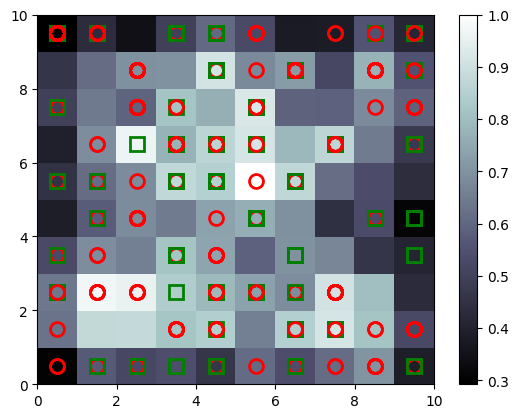

In [41]:
#Visualizing The Results
from pylab import bone, pcolor, plot, show, colorbar

bone()
pcolor(som.distance_map().T)
colorbar()
markers = ['o', 's']
colors = ['r', 'g']

for i, X in enumerate(x):
    w = som.winner(X)
    plot(w[0] + 0.5, 
         w[1] + 0.5,
         markers[y[i]],
         markeredgecolor = colors[y[i]],
         markerfacecolor = 'None',
         markersize = 10, 
         markeredgewidth = 2)
show()


In [45]:
#Finding the frauds

mappings = som.win_map(x)
frauds = np.concatenate((mappings[(8,1)], mappings[(6,8)]), axis = 0)
frauds = sc.inverse_transform(frauds)
print(frauds)

[[1.5810485e+07 1.0000000e+00 3.4170000e+01 2.7500000e+00 2.0000000e+00
  3.0000000e+00 5.0000000e+00 2.5000000e+00 0.0000000e+00 0.0000000e+00
  0.0000000e+00 1.0000000e+00 2.0000000e+00 2.3200000e+02 2.0100000e+02]
 [1.5758477e+07 1.0000000e+00 2.6920000e+01 2.2500000e+00 2.0000000e+00
  3.0000000e+00 5.0000000e+00 5.0000000e-01 0.0000000e+00 0.0000000e+00
  0.0000000e+00 1.0000000e+00 2.0000000e+00 6.4000000e+02 4.0010000e+03]
 [1.5726466e+07 1.0000000e+00 1.7420000e+01 6.5000000e+00 2.0000000e+00
  3.0000000e+00 4.0000000e+00 1.2500000e-01 0.0000000e+00 0.0000000e+00
  0.0000000e+00 0.0000000e+00 2.0000000e+00 6.0000000e+01 1.0100000e+02]
 [1.5692408e+07 1.0000000e+00 4.8080000e+01 6.0400000e+00 2.0000000e+00
  4.0000000e+00 4.0000000e+00 4.0000000e-02 0.0000000e+00 0.0000000e+00
  0.0000000e+00 0.0000000e+00 2.0000000e+00 0.0000000e+00 2.6910000e+03]
 [1.5694530e+07 1.0000000e+00 4.1170000e+01 1.3350000e+00 2.0000000e+00
  2.0000000e+00 4.0000000e+00 1.6500000e-01 0.0000000e+00 0.